#### MPAS Vertical Cross Section plotting
- Read MPAS cells
- Cross section setup
- specify pressure levels 
- Read MPAS data 
- Vertical interpolation: interpolating the data from the model's vertical grid to a user-specified pressure levels
- Horizonatal interpolation:  use scipy.interpolate to compute cross-section interpolation     
- Create the figure
  
Ming Ge

In [21]:
%matplotlib inline
 
import numpy as np
import xarray as xr

import matplotlib.tri as tri
import matplotlib.pyplot as plt
 
from scipy.interpolate import griddata 

In [22]:
def vertical_interpolate_mpas(vcoord_2d, vinterp_2d, plev_1d):
    '''
    A function to interpolate MPAS grid data  to
    specified millibar. Assumes a log-linear relationship.
    input:
        vcoord_2d  : 2D vertical level values (e.g., pressure )
        vinterp_2d : 2D array of the variable to be interpolated to all pressure levels
        plev_1d    : 1D array containing veritcal levels to interpolate to
    return:
        interp_2d : 2D array that contains the interpolated variable on the interp_levels
    '''
    interp_2d = np.empty((len(plev_1d), vinterp_2d.shape[0]))
    
    for nc in range(vinterp_2d.shape[0]):
       interp_2d[:,nc] = vertical_interpolate(vcoord_2d[nc].values, vinterp_2d[nc].values, plev_1d)    
    
    return interp_2d


# from https://github.com/Unidata/python-training/blob/master/pages/gallery/Observational_Data_Cross_Section.ipynb
# The vertical interpolation assumes a log-linear relationship.
def vertical_interpolate(vcoord_data, interp_var, interp_levels):
    """
    A function to interpolate sounding data from each station to
    every millibar. Assumes a log-linear relationship.

    Input
    -----
    vcoord_data : A 1D array of vertical level values (e.g., pressure from a radiosonde)
    interp_var : A 1D array of the variable to be interpolated to all pressure levels
    interp_levels : A 1D array containing veritcal levels to interpolate to

    Return
    ------
    interp_data : A 1D array that contains the interpolated variable on the interp_levels
    """

    # Make veritcal coordinate data and grid level log variables
    lnp = np.log(vcoord_data)
    lnp_intervals = np.log(interp_levels)

    # Use numpy to interpolate from observed levels to grid levels
    interp_data = np.interp(lnp_intervals[::-1], lnp[::-1], interp_var[::-1])[::-1]

    # Mask for missing data (generally only near the surface)
    mask_low = interp_levels > vcoord_data[0]
    mask_high = interp_levels < vcoord_data[-1]
    interp_data[mask_low] = interp_var[0]
    interp_data[mask_high] = interp_var[-1]

    return interp_data

#### Read MPAS Cells

In [23]:
dir_data = '/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/240km_uniform/'
flnm_ini = dir_data + 'x1.10242.init.nc'
ds_i = xr.open_dataset(flnm_ini)
ds_i = ds_i.squeeze()

# Convert to degrees from radians
ds_i["lonCell"] = np.degrees(ds_i.lonCell)
ds_i["latCell"] = np.degrees(ds_i.latCell)

# For Global tripcolor plot
# Add cyclic point before computing the triangulation
ds_i["lonCell"] = ((ds_i["lonCell"] + 180) % 360) - 180

# MPAS data point coordinates.
points = np.array([ds_i["lonCell"].values , ds_i["latCell"].values]).transpose()

triang = tri.Triangulation(ds_i.lonCell, ds_i.latCell)

#### Cross section setup

In [24]:
# # Create the start point and end point for the cross section
# Points at which to interpolate data.
lat_start, lon_start = (39,-120)
lat_end, lon_end = (39, -70)

# number of sample between start and end point
n_pt = 50
lat_1d = np.linspace(lat_start, lat_end, n_pt)
lon_1d = np.linspace(lon_start, lon_end, n_pt)

##### specify pressure levels 

In [25]:
# veritcal levels to interpolate to
p_1d = np.atleast_1d(np.arange(1000, 50, -100)) # hPa
n_p = len(p_1d)

##### Read MPAS data  

In [26]:
# the variable to be interpolated 
var_s = 'theta'

flnm = dir_data + 'restart.2014-09-11_00.00.00.nc'
print(flnm)
ds = xr.open_dataset(flnm)
ds = ds.squeeze()

theta = ds[var_s]              # theta(nCells, nVertLevels)
pressure_b = ds.pressure_base  # pressure_base(nCells, nVertLevels)
pressure_p = ds.pressure_p     # pressure_p(nCells, nVertLevels)
 
pres = 0.01*(pressure_b + pressure_p)  #hPa

/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/240km_uniform/restart.2014-09-11_00.00.00.nc


##### Vertical interpolation

In [27]:
var_2d = vertical_interpolate_mpas(pres, theta, p_1d)

##### Horizontal interpolation

In [28]:
hh_2d = np.empty((n_p, n_pt))

ct = 0
for nn in p_1d:
    # method='linear', 'cubic', 'nearest'
    hh_2d[ct, :] = griddata(points, var_2d[ct,:], (lon_1d, lat_1d), method='linear')
    ct = ct + 1    

##### Plotting

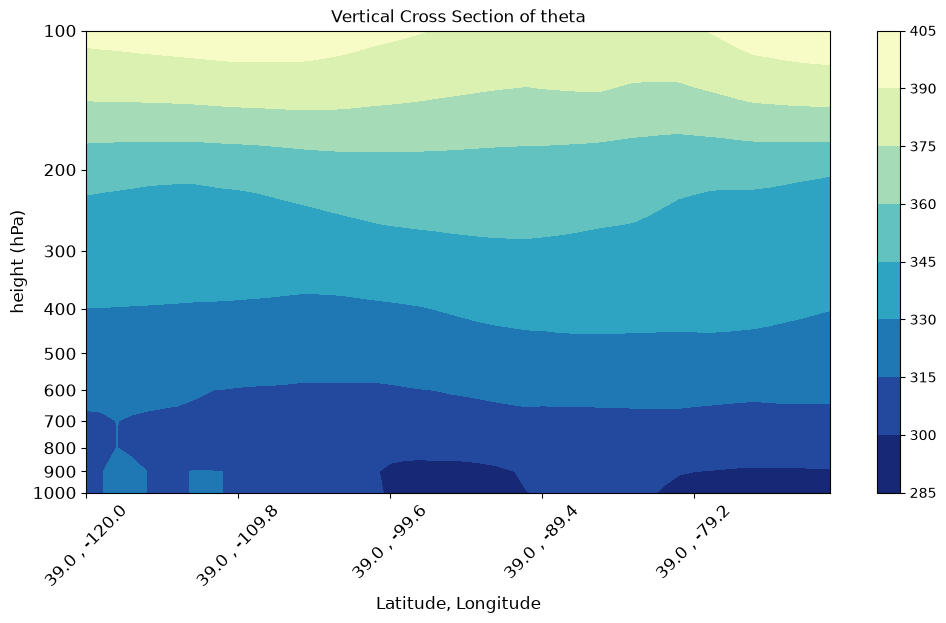

In [29]:
# Create the figure
fig = plt.figure(figsize=(12,6))
ax = plt.axes()

# Make the contour plot
# contourf([X= range(N), Y= range(M),] Z(M, N), [levels], **kwargs)
t_cs = ax.contourf(np.arange(n_pt), np.arange(1000, 50, -100), hh_2d, cmap='YlGnBu_r')

# Add the color bar
plt.colorbar(t_cs, ax=ax)

# Set the x-ticks to use latitude and longitude labels.
x_labels = ["%.1f" % pair[1] + ' , ' +  "%.1f" % pair[0] for pair in np.array([lon_1d, lat_1d]).transpose()]
ax.set_xticks(np.arange(n_pt)[::10])
ax.set_xticklabels(x_labels[::10], rotation=45, fontsize=12);

# Set the y-ticks to be height and adjust the y-axis to be logarithmic
ax.set_yscale('symlog')
ax.set_ylim(p_1d.max(), p_1d.min())
ax.set_yticks(np.arange(1000, 50, -100))
ax.set_yticklabels(p_1d, fontsize=12)

# Set the x-axis and  y-axis labels
ax.set_xlabel("Latitude, Longitude", fontsize=12)
ax.set_ylabel("height (hPa)", fontsize=12)

plt.title("Vertical Cross Section of theta");